# Sparse vs Dense Scaling

**Model.** This notebook compares dense and sparse matrix construction for selected tight-binding and Hubbard builders. Sparse matrices store only nonzero entries and are useful for low-energy calculations.

**Typical uses.** Memory-scaling checks, deciding when to switch to sparse workflows, low-energy spectra with `eigsh`, and sanity checks that sparse and dense builders agree.

**Parameters.** `n_sites`, `n_rows`, `n_cols`, and `max_occupancy` drive dimension growth. `nnz` counts sparse nonzero entries. `lowest_eigenvalues(H, k)` computes low-energy values with sparse solvers for sparse matrices.

**Useful plots.** Dimension and nonzero-count tables, sparse/dense eigenvalue agreement, and low-energy spectra.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from quantum_lattice_models.models import (
    bose_hubbard_chain,
    bose_hubbard_chain_sparse,
    fermi_hubbard_chain,
    fermi_hubbard_chain_sparse,
    square_lattice_tight_binding,
    square_lattice_tight_binding_sparse,
)
from quantum_lattice_models.spectra import eigenvalues, lowest_eigenvalues

In [2]:
comparisons = []
for n in [2, 3, 4]:
    dense = bose_hubbard_chain(n_sites=n, max_occupancy=2)
    sparse = bose_hubbard_chain_sparse(n_sites=n, max_occupancy=2)
    comparisons.append((f"Bose n={n}", dense.shape[0], sparse.nnz, sparse.nnz / dense.size))
for n in [2, 3]:
    dense = fermi_hubbard_chain(n_sites=n)
    sparse = fermi_hubbard_chain_sparse(n_sites=n)
    comparisons.append((f"Fermi n={n}", dense.shape[0], sparse.nnz, sparse.nnz / dense.size))
for rows, cols in [(4, 4), (6, 6)]:
    dense = square_lattice_tight_binding(rows, cols)
    sparse = square_lattice_tight_binding_sparse(rows, cols)
    comparisons.append(
        (f"Square {rows}x{cols}", dense.shape[0], sparse.nnz, sparse.nnz / dense.size)
    )

print("model          | dimension | nonzeros | sparse density")
print("---            | ---       | ---      | ---")
for label, dimension, nnz, density in comparisons:
    print(f"{label:<14s} | {dimension:>9d} | {nnz:>8d} | {density:.4f}")

model          | dimension | nonzeros | sparse density
---            | ---       | ---      | ---
Bose n=2       |         9 |       13 | 0.1605
Bose n=3       |        27 |       67 | 0.0919
Bose n=4       |        81 |      281 | 0.0428
Fermi n=2      |        16 |       23 | 0.0898
Fermi n=3      |        64 |      165 | 0.0403
Square 4x4     |        16 |       48 | 0.1875
Square 6x6     |        36 |      120 | 0.0926


In [3]:
dense = square_lattice_tight_binding(3, 3)
sparse = square_lattice_tight_binding_sparse(3, 3)
dense_lowest = eigenvalues(dense)[:4]
sparse_lowest = lowest_eigenvalues(sparse, k=4)
print("Square 3x3 lowest eigenvalues")
print("  dense: ", np.array2string(dense_lowest, precision=6, separator=", "))
print("  sparse:", np.array2string(sparse_lowest, precision=6, separator=", "))

Square 3x3 lowest eigenvalues
  dense:  [-2.828427e+00, -1.414214e+00, -1.414214e+00, -1.737460e-16]
  sparse: [-2.828427e+00, -1.414214e+00, -1.414214e+00, -1.906322e-18]


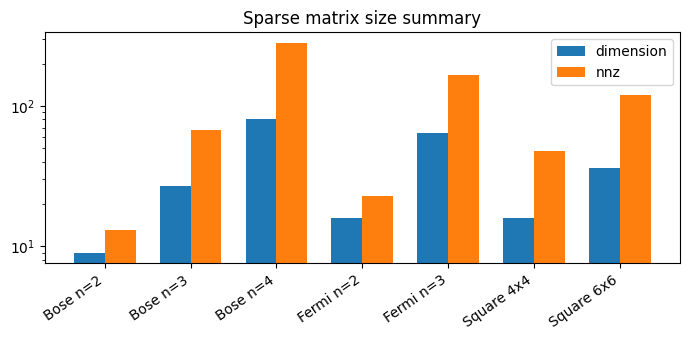

In [4]:
labels = [row[0] for row in comparisons]
dimensions = [row[1] for row in comparisons]
nnz = [row[2] for row in comparisons]

fig, ax = plt.subplots(figsize=(7, 3.5))
x = np.arange(len(labels))
ax.bar(x - 0.18, dimensions, width=0.36, label="dimension")
ax.bar(x + 0.18, nnz, width=0.36, label="nnz")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha="right")
ax.set_yscale("log")
ax.set_title("Sparse matrix size summary")
ax.legend()
fig.tight_layout()